In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load results
npz = np.load(
    r"E:\TUM\3sem\NeuroAI\project\github_neuroai\results\size_comparison\CDM_results\pid_sweep_cdm\sweep_results.npz",
    allow_pickle=True
)

print("Keys in the NPZ file:", npz.files)

# Inspect contents
for key in npz.files:
    arr = npz[key]
    print(f"{key}: shape={getattr(arr, 'shape', None)}, dtype={arr.dtype}")

Keys in the NPZ file: ['h2_coherence_synergy', 'h2_coherence_redundancy', 'h2_coherence_unique1', 'h2_coherence_unique2', 'h2_coherence_mi_joint', 'h2_coherence_stim_end', 'h2_context_synergy', 'h2_context_redundancy', 'h2_context_unique1', 'h2_context_unique2', 'h2_context_mi_joint', 'h2_context_stim_end', 'h2_losses', 'h4_coherence_synergy', 'h4_coherence_redundancy', 'h4_coherence_unique1', 'h4_coherence_unique2', 'h4_coherence_mi_joint', 'h4_coherence_stim_end', 'h4_context_synergy', 'h4_context_redundancy', 'h4_context_unique1', 'h4_context_unique2', 'h4_context_mi_joint', 'h4_context_stim_end', 'h4_losses', 'h8_coherence_synergy', 'h8_coherence_redundancy', 'h8_coherence_unique1', 'h8_coherence_unique2', 'h8_coherence_mi_joint', 'h8_coherence_stim_end', 'h8_context_synergy', 'h8_context_redundancy', 'h8_context_unique1', 'h8_context_unique2', 'h8_context_mi_joint', 'h8_context_stim_end', 'h8_losses', 'h12_coherence_synergy', 'h12_coherence_redundancy', 'h12_coherence_unique1', 'h

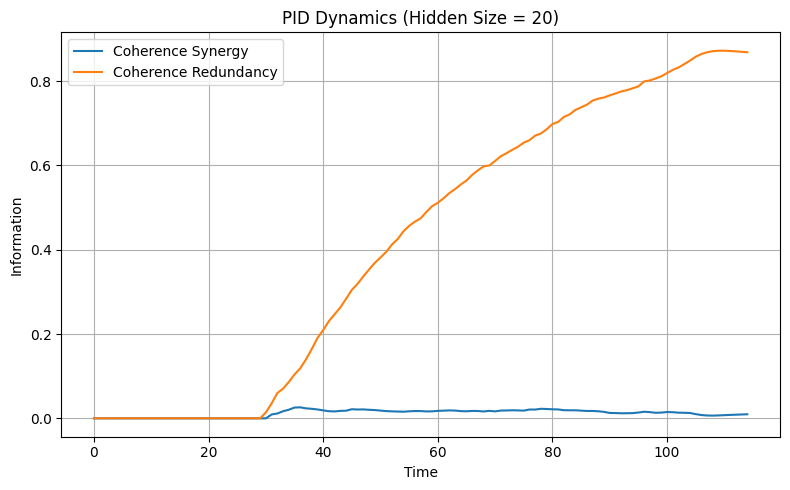

In [3]:
import numpy as np
import matplotlib.pyplot as plt

npz = np.load(
    r"E:\TUM\3sem\NeuroAI\project\github_neuroai\results\size_comparison\CDM_results\pid_sweep_cdm\sweep_results.npz"
)

h = 20

plt.figure(figsize=(8,5))

plt.plot(npz[f"h{h}_coherence_synergy"], label="Coherence Synergy")
plt.plot(npz[f"h{h}_coherence_redundancy"], label="Coherence Redundancy")

plt.xlabel("Time")
plt.ylabel("Information")
plt.title(f"PID Dynamics (Hidden Size = {h})")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

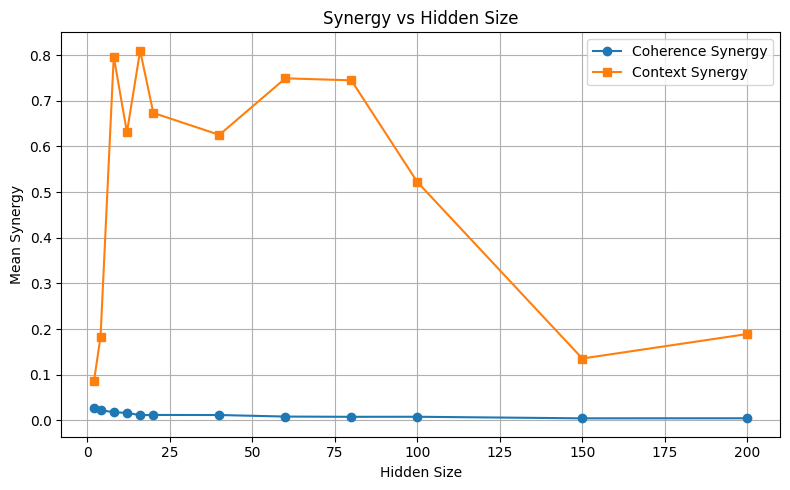

In [4]:
import numpy as np
import matplotlib.pyplot as plt

npz = np.load(
    r"E:\TUM\3sem\NeuroAI\project\github_neuroai\results\size_comparison\CDM_results\pid_sweep_cdm\sweep_results.npz"
)

hidden_sizes = [2,4,8,12,16,20,40,60,80,100,150,200]

coh_syn = []
ctx_syn = []

for h in hidden_sizes:
    coh_syn.append(np.mean(npz[f"h{h}_coherence_synergy"]))
    ctx_syn.append(np.mean(npz[f"h{h}_context_synergy"]))

plt.figure(figsize=(8,5))

plt.plot(hidden_sizes, coh_syn, marker='o', label="Coherence Synergy")
plt.plot(hidden_sizes, ctx_syn, marker='s', label="Context Synergy")

plt.xlabel("Hidden Size")
plt.ylabel("Mean Synergy")
plt.title("Synergy vs Hidden Size")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

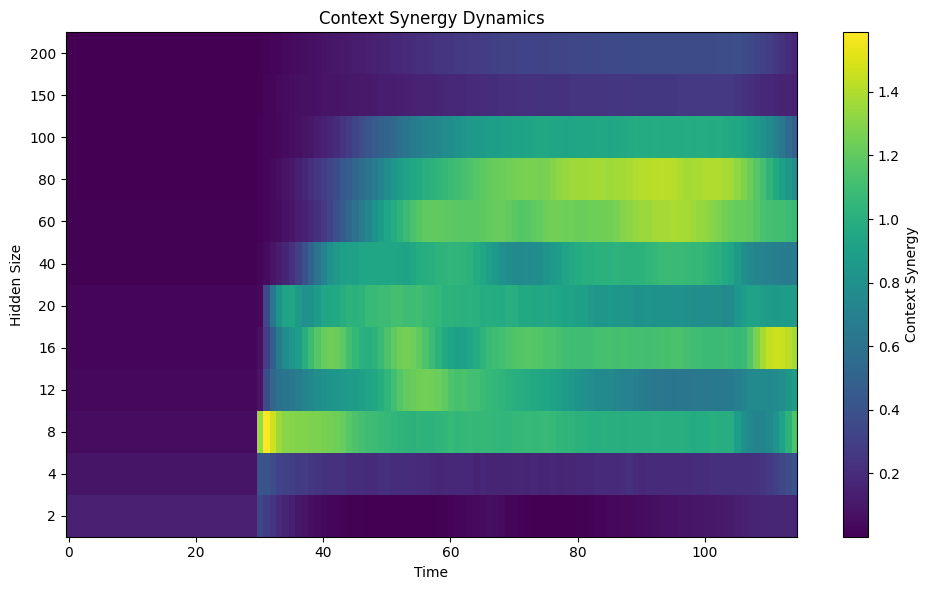

In [5]:
import numpy as np
import matplotlib.pyplot as plt

npz = np.load(
    r"E:\TUM\3sem\NeuroAI\project\github_neuroai\results\size_comparison\CDM_results\pid_sweep_cdm\sweep_results.npz"
)

hidden_sizes = [2,4,8,12,16,20,40,60,80,100,150,200]

heatmap = np.array([
    npz[f"h{h}_context_synergy"]
    for h in hidden_sizes
])

plt.figure(figsize=(10,6))

plt.imshow(
    heatmap,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Context Synergy")

plt.yticks(
    np.arange(len(hidden_sizes)),
    hidden_sizes
)

plt.xlabel("Time")
plt.ylabel("Hidden Size")
plt.title("Context Synergy Dynamics")

plt.tight_layout()
plt.show()

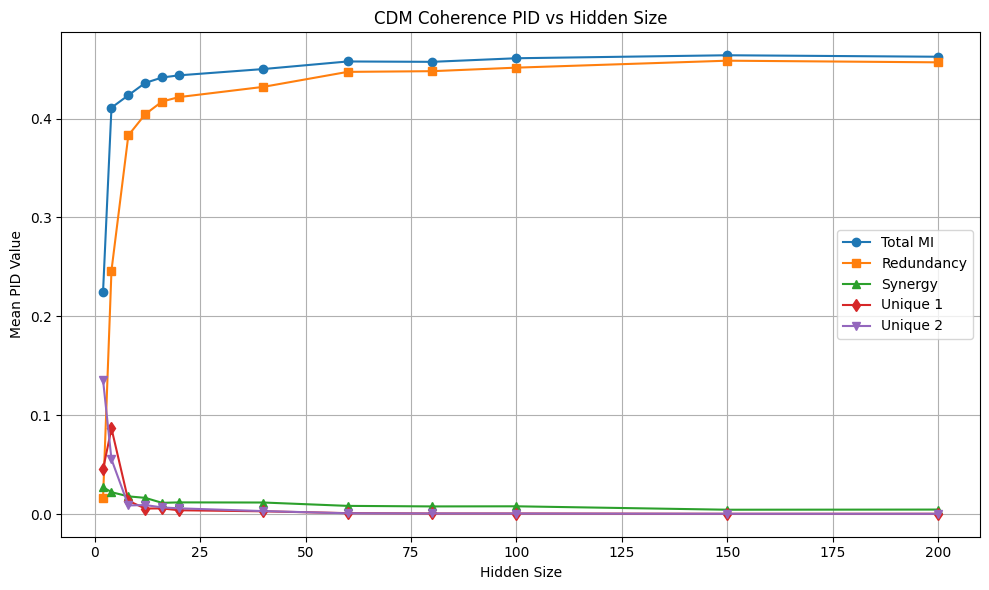

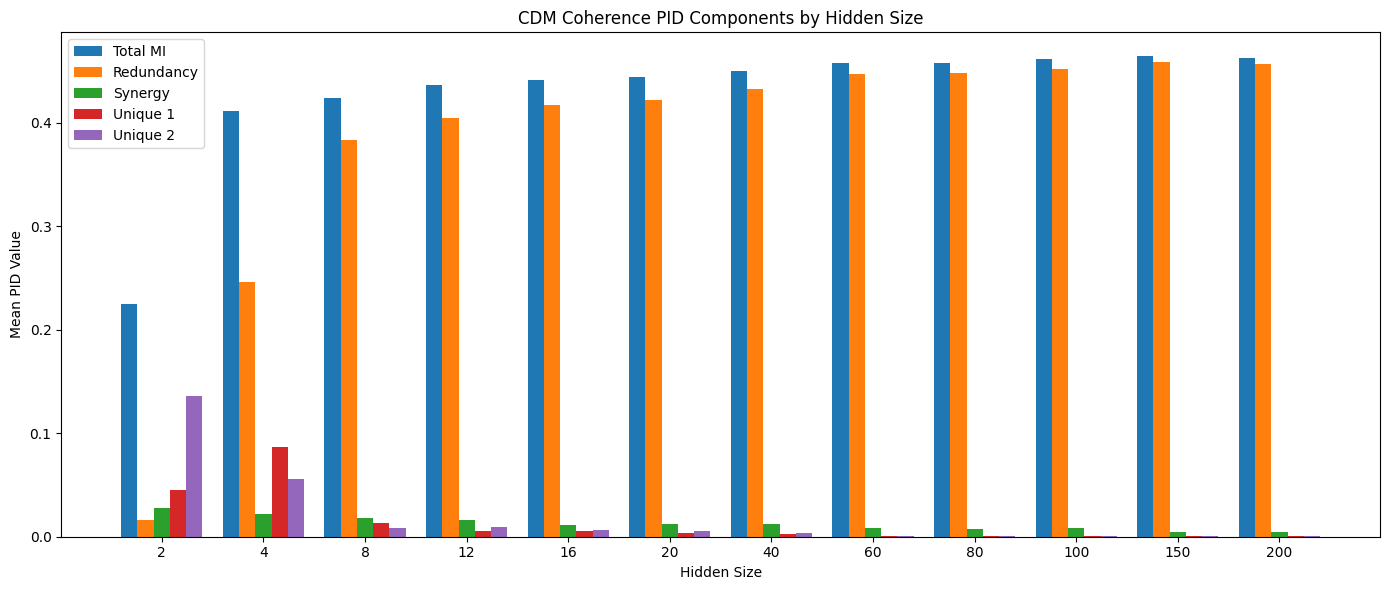

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
npz = np.load(
    r"E:\TUM\3sem\NeuroAI\project\github_neuroai\results\size_comparison\CDM_results\pid_sweep_cdm\sweep_results.npz"
)

hidden_sizes = [2, 4, 8, 12, 16, 20, 40, 60, 80, 100, 150, 200]

# -----------------------------
# Collect summary statistics
# -----------------------------
mi = []
red = []
syn = []
uniq1 = []
uniq2 = []

for h in hidden_sizes:

    # Context PID
    mi.append(
        np.mean(npz[f"h{h}_coherence_mi_joint"])
    )

    red.append(
        np.mean(npz[f"h{h}_coherence_redundancy"])
    )

    syn.append(
        np.mean(npz[f"h{h}_coherence_synergy"])
    )

    uniq1.append(
        np.mean(npz[f"h{h}_coherence_unique1"])
    )

    uniq2.append(
        np.mean(npz[f"h{h}_coherence_unique2"])
    )

mi = np.array(mi)
red = np.array(red)
syn = np.array(syn)
uniq1 = np.array(uniq1)
uniq2 = np.array(uniq2)

# =====================================================
# Figure 1: Hidden Size vs PID Components (Line Plot)
# =====================================================

plt.figure(figsize=(10, 6))

plt.plot(hidden_sizes, mi, marker='o', label='Total MI')
plt.plot(hidden_sizes, red, marker='s', label='Redundancy')
plt.plot(hidden_sizes, syn, marker='^', label='Synergy')
plt.plot(hidden_sizes, uniq1, marker='d', label='Unique 1')
plt.plot(hidden_sizes, uniq2, marker='v', label='Unique 2')

plt.xlabel("Hidden Size")
plt.ylabel("Mean PID Value")
plt.title("CDM Coherence PID vs Hidden Size")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("pid_vs_hidden_size.png", dpi=300)
plt.show()


# =====================================================
# Figure 2: Grouped Bar Plot
# =====================================================

x = np.arange(len(hidden_sizes))
width = 0.16

plt.figure(figsize=(14, 6))

plt.bar(x - 2*width, mi, width, label='Total MI')
plt.bar(x - width, red, width, label='Redundancy')
plt.bar(x, syn, width, label='Synergy')
plt.bar(x + width, uniq1, width, label='Unique 1')
plt.bar(x + 2*width, uniq2, width, label='Unique 2')

plt.xticks(x, hidden_sizes)

plt.xlabel("Hidden Size")
plt.ylabel("Mean PID Value")
plt.title("CDM Coherence PID Components by Hidden Size")

plt.legend()
plt.tight_layout()

plt.savefig("pid_barplot_hidden_size.png", dpi=300)
plt.show()